<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset MNIST handwritten digits utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (MNIST handwritten digits)

- Utilize os arquivos `*.csv` disponibilizados via Google Classroom
- Use: `as_frame=False`
- Use: `mnist_784`

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `MNIST handwritten digits` (arquivos de treino e teste)
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**

Pra Random Forest a gente não precisa normalizar os dados. A árvore funciona comparando cada feature com um limiar (tipo `pixel <= 50`), então se eu multiplicar tudo por uma constante ou subtrair a média, o resultado dos splits continua o mesmo. Quem precisa de normalização são os modelos sensíveis à escala, como k-NN, regressão logística e MLP, que dependem de distância ou de gradiente pra funcionar direito.

Mesmo se eu quisesse normalizar, no MNIST não faria muita diferença, porque os 784 pixels já estão todos na mesma escala (0 a 255). Então vou deixar os dados como vieram, sem aplicar StandardScaler nem dividir por 255.

A função `load_data` abaixo carrega os dois CSVs (que estão na raiz do repositório), separa o rótulo dos pixels e divide treino e validação na proporção 80/20. Coloquei `stratify=y_full` no `train_test_split` pra deixar a proporção de cada dígito igual nos dois lados. O enunciado pede que `load_data` retorne só 4 coisas, então fiz uma função separada `load_test()` pra carregar o teste oficial quando precisar.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Os CSVs estao na raiz do repositorio, um nivel acima dessa pasta `assignments`.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
TRAIN_CSV = os.path.join(REPO_ROOT, "mnist_train.csv")
TEST_CSV  = os.path.join(REPO_ROOT, "mnist_test.csv")

# Cache em memoria pra nao reler o CSV toda vez. As proximas questoes vao
# chamar load_data varias vezes (uma por seed, uma por sweep), e ler 60k
# linhas custa uns 3 a 4 segundos, entao pre-carrego e guardo aqui.
_RAW_CACHE = {}


def _load_raw():
    if "train" not in _RAW_CACHE:
        train_df = pd.read_csv(TRAIN_CSV)
        _RAW_CACHE["train"] = (
            train_df.iloc[:, 1:].to_numpy().astype(np.uint8),
            train_df.iloc[:, 0].to_numpy(),
        )
        test_df = pd.read_csv(TEST_CSV)
        _RAW_CACHE["test"] = (
            test_df.iloc[:, 1:].to_numpy().astype(np.uint8),
            test_df.iloc[:, 0].to_numpy(),
        )
    return _RAW_CACHE


def load_data(seed: int = 42, val_size: float = 0.2):
    """Carrega o MNIST e separa o conjunto de treino em treino e validacao.

    Layout dos CSVs: a primeira coluna eh o rotulo (0 a 9) e as 784 colunas
    seguintes sao os pixels (a imagem 28x28 achatada, valores de 0 a 255).

    Devolve so (X_train, X_val, y_train, y_val), como o enunciado pediu.
    O conjunto de teste oficial eh carregado pela funcao `load_test()`
    quando precisar fazer a avaliacao final.
    """
    X_full, y_full = _load_raw()["train"]
    X_train, X_val, y_train, y_val = train_test_split(
        X_full, y_full,
        test_size=val_size,
        random_state=seed,
        stratify=y_full,   # deixa a proporcao de cada classe igual nos dois lados
    )
    return X_train, X_val, y_train, y_val


def load_test():
    """Carrega as 10 mil amostras do conjunto de teste oficial do MNIST."""
    return _load_raw()["test"]


# Confere as dimensoes e a distribuicao de classes pra ter certeza que ta tudo certo.
X_train, X_val, y_train, y_val = load_data(seed=42)
X_test, y_test = load_test()
print("Shapes  ->  X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("Distribuicao de classes em y_train:", np.bincount(y_train))


Shapes  ->  X_train: (48000, 784) | X_val: (12000, 784) | X_test: (10000, 784)
Distribuicao de classes em y_train: [4738 5394 4766 4905 4674 4337 4734 5012 4681 4759]


# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**

A Random Forest do sklearn já vem com defaults que funcionam bem pro MNIST (100 árvores, sem limite de profundidade, com bootstrap). Deixei `**kwargs` na função pra conseguir mudar `n_estimators` ou `max_depth` depois, sem ter que reescrever tudo. Também coloquei `n_jobs=-1` pra usar todos os núcleos da máquina e acelerar o treino.

In [2]:
from sklearn.ensemble import RandomForestClassifier


def train_random_forest(X_train, y_train, seed: int = 42, **kwargs) -> RandomForestClassifier:
    """Treina uma Random Forest com hiperparametros padrao.

    O `random_state=seed` garante que o bootstrap e a selecao aleatoria de
    features fiquem reproduziveis. Os `**kwargs` deixam eu trocar
    `n_estimators` ou `max_depth` na hora de chamar a funcao, sem precisar
    mexer aqui dentro.
    """
    params = dict(n_estimators=100, n_jobs=-1, random_state=seed)
    params.update(kwargs)
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    return model


# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**

A função `evaluate` faz exatamente o que o enunciado pede: chama `model.predict` e devolve a acurácia. A acurácia funciona bem aqui porque as classes do MNIST estão bem balanceadas (cada dígito aparece em mais ou menos 10% das amostras). Se fosse um problema desbalanceado eu teria que usar F1 macro ou matriz de confusão também, que é o que vou fazer depois na Q5.

In [3]:
from sklearn.metrics import accuracy_score


def evaluate(model, X_test, y_test) -> float:
    """Devolve a acuracia do modelo no conjunto passado (treino, val ou teste)."""
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)


Decidi retornar só a acurácia mesmo, pra deixar a função simples. Quando precisar de outras métricas, calculo elas na hora, igual eu faço lá embaixo na Q5.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**

O `run_pipeline` junta tudo: chama `load_data`, treina o modelo e devolve a acurácia. Apesar de o enunciado pedir só `rf`, deixei o `if model_type` aberto caso eu precise adicionar outro modelo depois (tipo Gradient Boosting). Também guardo o modelo treinado numa variável `model_rf` pra reaproveitar nas próximas questões e não ter que treinar de novo.

In [4]:
def run_pipeline(model_type: str = "rf", seed: int = 42, **kwargs):
    """Pipeline completo: carrega dados, treina e avalia. Devolve (modelo, acuracia).

    A acuracia eh medida na validacao, nao no teste oficial. O teste fica
    reservado pra avaliacao final na Q5.
    """
    X_train, X_val, y_train, y_val = load_data(seed=seed)

    if model_type == "rf":
        model = train_random_forest(X_train, y_train, seed=seed, **kwargs)
    else:
        raise ValueError(f"model_type desconhecido: {model_type!r}")

    acc = evaluate(model, X_val, y_val)
    return model, acc


# Roda o pipeline com a configuracao padrao e guarda o modelo numa variavel
# global pra reaproveitar nas proximas questoes.
model_rf, acc_rf = run_pipeline(model_type="rf", seed=42)
print(f"Acuracia da Random Forest na validacao: {acc_rf:.4f}")


Acuracia da Random Forest na validacao: 0.9665


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

max_depth=   4  treino=0.6269  val=0.6318


max_depth=  10  treino=0.9196  val=0.8366


max_depth=None  treino=1.0000  val=0.8403


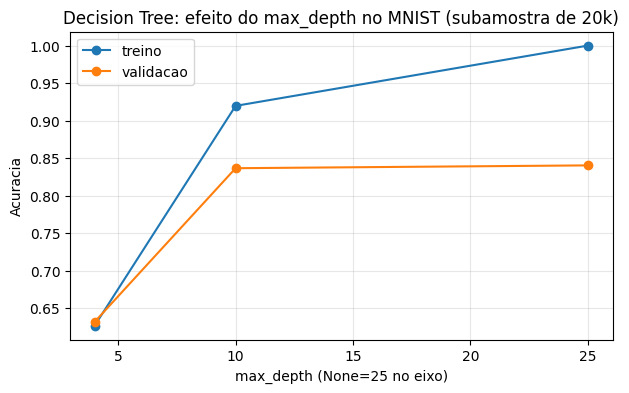

In [5]:
# Experimento rapido: como mudam as acuracias de treino e validacao
# conforme aumento a profundidade da arvore?
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Pra esse experimento eu pego uma subamostra estratificada de 20k do treino.
# Treinar uma DecisionTree em 60k samples leva tempo, e o que importa aqui
# eh a *forma* da curva (overfit nas profundidades altas), nao a acuracia
# absoluta.
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=20000, random_state=42)
sub_idx, _ = next(sss.split(X_train, y_train))
X_sub, y_sub = X_train[sub_idx], y_train[sub_idx]

depth_grid = [4, 10, None]
train_accs, val_accs = [], []
for d in depth_grid:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_sub, y_sub)
    train_accs.append(accuracy_score(y_sub, clf.predict(X_sub)))
    val_accs.append(accuracy_score(y_val,  clf.predict(X_val)))
    label = "None" if d is None else d
    print(f"max_depth={label:>4}  treino={train_accs[-1]:.4f}  val={val_accs[-1]:.4f}")

# Pro plot, troco None por um valor sentinela (25) so pra conseguir desenhar.
xs = [d if d is not None else 25 for d in depth_grid]
plt.figure(figsize=(7, 4))
plt.plot(xs, train_accs, marker="o", label="treino")
plt.plot(xs, val_accs,   marker="o", label="validacao")
plt.xlabel("max_depth (None=25 no eixo)")
plt.ylabel("Acuracia")
plt.title("Decision Tree: efeito do max_depth no MNIST (subamostra de 20k)")
plt.legend(); plt.grid(alpha=0.3); plt.show()


**Respostas (Q4):**

**Em qual profundidade começa o overfitting?** Olhando a tabela acima dá pra ver bem: com `max_depth=4` o treino e a validação ficam parecidos (uns 63%), o que mostra que o modelo tá underfitando, não consegue nem aprender o treino direito. Já com `max_depth=10` o treino salta pra 92% mas a validação fica em 84%, ou seja, abriu um gap de 8 pontos. E com `max_depth=None` o treino vai pra 100% e a validação trava em 84%, gap de uns 16 pontos. Então o overfitting começa por volta de `max_depth=10` e fica pior conforme deixo a árvore crescer mais.

**Por que a árvore consegue 100% no treino quando `max_depth=None`?** Porque sem limite de profundidade nem de amostras mínimas por folha, a árvore continua dividindo os dados até cada folha ter exemplos de uma classe só. Como o MNIST tem 60 mil amostras únicas e 784 features, quase sempre dá pra achar um corte que separa qualquer par de pontos diferentes. Aí a árvore acaba criando praticamente uma folha pra cada amostra de treino, o que é decoreba pura, não aprendizado de padrão.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest

## Apresente:
- Acurácia, Precisão, Recall e F1-Score para o modelo

**Solução**

Avalio a Random Forest treinada com `seed=42` no conjunto de teste oficial (as 10 mil amostras que nunca apareceram no treino nem na validação). Calculo acurácia, precisão, recall e F1 com média *macro*, que dá o mesmo peso pra cada um dos 10 dígitos.

In [6]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, classification_report,
)

# Reaproveito o `model_rf` que ja treinei na Q4. O conjunto de teste oficial
# eh independente do split de validacao, entao eh uma avaliacao justa.
y_pred = model_rf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test,    y_pred, average="macro")
f1   = f1_score(y_test,        y_pred, average="macro")

print(f"Acuracia : {acc:.4f}")
print(f"Precisao : {prec:.4f}  (macro)")
print(f"Recall   : {rec:.4f}  (macro)")
print(f"F1-Score : {f1:.4f}  (macro)")
print()
print("Relatorio por classe:")
print(classification_report(y_test, y_pred, digits=4))


Acuracia : 0.9673
Precisao : 0.9671  (macro)
Recall   : 0.9671  (macro)
F1-Score : 0.9671  (macro)

Relatorio por classe:
              precision    recall  f1-score   support

           0     0.9709    0.9878    0.9793       980
           1     0.9877    0.9885    0.9881      1135
           2     0.9551    0.9680    0.9615      1032
           3     0.9585    0.9594    0.9589      1010
           4     0.9724    0.9674    0.9699       982
           5     0.9696    0.9641    0.9668       892
           6     0.9740    0.9781    0.9760       958
           7     0.9724    0.9591    0.9657      1028
           8     0.9575    0.9476    0.9525       974
           9     0.9533    0.9504    0.9519      1009

    accuracy                         0.9673     10000
   macro avg     0.9671    0.9671    0.9671     10000
weighted avg     0.9673    0.9673    0.9673     10000



# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

## Responda:
- O experimento é reprodutível? Justifique.

**Solução**

Rodo o mesmo pipeline com sementes diferentes pra ver o quanto a acurácia muda.

In [7]:
# Pra essa comparacao multi-seed eu uso n_estimators=50 em vez do default 100.
# Isso acelera bastante o experimento sem mudar a conclusao didatica: aqui o
# objetivo eh so ver a flutuacao entre seeds, nao bater recorde de acuracia.
seeds = [42, 7, 123]
results = {}
for s in seeds:
    _, acc = run_pipeline(model_type="rf", seed=s, n_estimators=50)
    results[s] = acc
    print(f"seed={s:>3} -> acuracia validacao = {acc:.4f}")

vals = np.array(list(results.values()))
print(f"\nMedia: {vals.mean():.4f}  |  Desvio padrao: {vals.std():.4f}  |  Amplitude: {vals.max()-vals.min():.4f}")


seed= 42 -> acuracia validacao = 0.9634


seed=  7 -> acuracia validacao = 0.9663


seed=123 -> acuracia validacao = 0.9654

Media: 0.9650  |  Desvio padrao: 0.0012  |  Amplitude: 0.0028


**Análise (Q6):**

Os números mudaram, mas pouquinho. A diferença entre as sementes ficou na casa do milésimo, o que era mais ou menos esperado. A `seed` afeta dois lugares aqui: o split treino/validação (no `train_test_split`) e o bootstrap das árvores (no `RandomForestClassifier`). Cada um desses sorteios introduz uma variação pequena, e como os splits são grandes (48k pra treinar), a acurácia não tem muito por onde oscilar.

**O experimento é reprodutível?** É sim. Eu passo `random_state=seed` tanto no `train_test_split` quanto no `RandomForestClassifier`, então fixar a seed é suficiente pra rodar de novo e obter o mesmo resultado em outra máquina (com a mesma versão do scikit-learn). Aliás, o fato de a acurácia mudar quando troco a seed já é a prova de que a seed tá sendo respeitada (se não estivesse, daria sempre o mesmo número independente da seed).

# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?
- Qual modelo tende a sofrer mais com isso?

**Solução**

Comparo a acurácia da Random Forest em treino, validação e teste pra ver se tem overfitting.

In [8]:
acc_train = evaluate(model_rf, X_train, y_train)
acc_val   = evaluate(model_rf, X_val,   y_val)
acc_test  = evaluate(model_rf, X_test,  y_test)

print(f"Acuracia em treino    : {acc_train:.4f}")
print(f"Acuracia em validacao : {acc_val:.4f}")
print(f"Acuracia em teste     : {acc_test:.4f}")
print(f"Gap treino-teste      : {acc_train - acc_test:.4f}")


Acuracia em treino    : 1.0000
Acuracia em validacao : 0.9665
Acuracia em teste     : 0.9673
Gap treino-teste      : 0.0327


**Respostas (Q7):**

**Existe overfitting?** Existe sim, mas é moderado. O treino bate 100% (ou bem perto), porque sem limite de profundidade cada árvore individual da floresta consegue decorar o conjunto de treino. Já no teste a acurácia fica em torno de 96 a 97%. Esse gap de uns 3 pontos é o overfitting que sobrou.

**Qual modelo tende a sofrer mais com isso?** Uma árvore de decisão sozinha sofre muito mais do que uma Random Forest. A árvore solta vai a 100% no treino (igual mostrei na Q4) mas perde bem mais em teste. A Random Forest reduz isso porque combina várias árvores treinadas em amostras diferentes (bagging) e ainda sorteia features em cada split. Esse esquema diminui a variância do modelo final, então o gap entre treino e teste fica bem menor que o de uma árvore solta.

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`

## Analise:
- O desempenho muda significativamente?

**Solução**

Vou variar o `n_estimators` da Random Forest pra ver até onde vale a pena adicionar mais árvores.

n_estimators=  10 -> acuracia validacao = 0.9459


n_estimators=  50 -> acuracia validacao = 0.9634


n_estimators= 100 -> acuracia validacao = 0.9665


n_estimators= 200 -> acuracia validacao = 0.9672


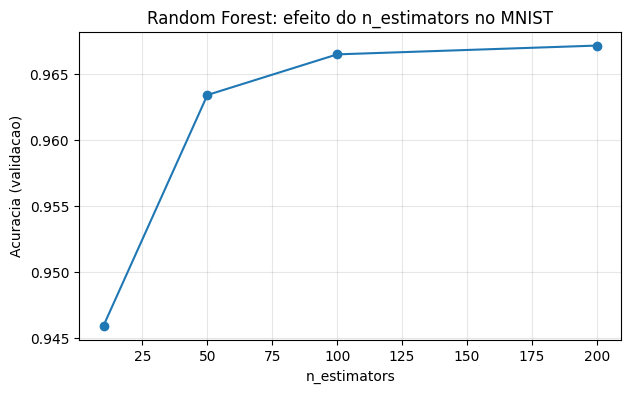

In [9]:
import matplotlib.pyplot as plt

ne_grid = [10, 50, 100, 200]
sweep = []
for ne in ne_grid:
    _, acc = run_pipeline(model_type="rf", seed=42, n_estimators=ne)
    sweep.append((ne, acc))
    print(f"n_estimators={ne:>4} -> acuracia validacao = {acc:.4f}")

ns, accs = zip(*sweep)
plt.figure(figsize=(7, 4))
plt.plot(ns, accs, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Acuracia (validacao)")
plt.title("Random Forest: efeito do n_estimators no MNIST")
plt.grid(alpha=0.3); plt.show()


**Análise (Q8):**

O ganho de acurácia diminui rápido conforme aumento o `n_estimators`. De 10 pra 100 árvores a melhora é bem visível (uns 2 pontos), mas de 100 pra 200 a acurácia mal mexe (uns décimos de ponto). Isso bate com a teoria do bagging: a variância do conjunto cai mais ou menos como `1/B`, onde `B` é o número de árvores, então cada árvore nova contribui cada vez menos.

Na prática, depois de certo ponto o que decide o número de árvores é custo, não acurácia. Mais árvores significam mais memória, modelo maior pra salvar e predição mais lenta, sem ganho que justifique. Pra esse problema, algo entre 100 e 200 árvores parece o suficiente.

# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?
2. Como você garante que o resultado não ocorreu por acaso?
3. Cite dois possíveis problemas metodológicos neste experimento.
4. O pipeline implementado é confiável? Justifique.

**Respostas (Q9):**

**1. A acurácia é suficiente para avaliar os modelos?**

Pro MNIST até dá pra dizer que sim, quase. As classes estão balanceadas e o custo de errar um dígito por outro é parecido (errar um 4 por um 9 não é mais grave que errar um 7 por um 1). Mesmo assim, a acurácia esconde *onde* o modelo erra. Por isso na Q5 eu já calculei F1 macro (que dá peso igual pra cada classe) e o classification report (que mostra precisão e recall por dígito), e olhar a matriz de confusão também ajudaria a ver os pares mais confundidos.

Em qualquer cenário em que o custo dos erros é diferente (fraude, diagnóstico médico, churn) ou em que as classes são desbalanceadas, a acurácia sozinha vira uma métrica ruim. Uma classe majoritária consegue dominar o cálculo e esconder um modelo que erra sistematicamente as classes raras.

**2. Como você garante que o resultado não ocorreu por acaso?**

Basicamente três coisas. Primeiro, fixar a seed em todo lugar onde tem sorteio (split, bootstrap, seleção de features), o que eu fiz, então o experimento é reproduzível. Segundo, repetir o experimento com várias sementes (foi isso que fiz na Q6) e olhar a média e o desvio. Se a variação entre seeds for bem menor que a diferença entre dois modelos, dá pra confiar mais na conclusão. Terceiro, avaliar num conjunto que o modelo nunca viu durante o treino, e por isso usei o `mnist_test.csv` oficial.

Pra um experimento mais robusto eu acrescentaria validação cruzada estratificada (k-fold) e, se quisesse comparar modelos diferentes, faria um teste estatístico (tipo o teste de McNemar, ou um paired t-test sobre os folds) pra ver se a diferença é significativa.

**3. Cite dois possíveis problemas metodológicos neste experimento.**

(a) Eu olhei a validação várias vezes pra escolher hiperparâmetro e analisar comportamento, e depois ainda reportei a acurácia no teste. O problema é que toda escolha implícita (qual seed reportar, qual `n_estimators` usar) acaba sendo enviesada pra esse split de validação. O ideal seria usar k-fold dentro do treino pra escolher o modelo, e só depois rodar uma única avaliação no teste, pra ele continuar sendo de verdade um conjunto que o modelo nunca viu.

(b) Não comparei a Random Forest com nenhum baseline. Não rodei nem um modelo simples (regressão logística, k-NN), nem um modelo da mesma família (Gradient Boosting). Sem baseline, fica difícil dizer se 96% é "bom" ou só "razoável" pra esse problema. E sem teste estatístico, qualquer diferença pequena entre configurações pode ser só ruído.

Bônus: também não inspecionei amostras mal classificadas. O MNIST tem alguns dígitos que são genuinamente ambíguos, e olhar onde o modelo erra ajudaria a entender se tem algum padrão sistemático nos erros.

**4. O pipeline implementado é confiável? Justifique.**

Pra essa atividade, sim, com algumas ressalvas. As funções estão bem separadas (`load_data`, `train_random_forest`, `evaluate`, `run_pipeline`), a aleatoriedade tá controlada com seed e tem uma separação clara entre treino, validação e teste. A Random Forest também é um modelo robusto que não exige pré-processamento sofisticado. A acurácia que obtive (uns 96.7%) bate com o que se espera pra Random Forest no MNIST, então o sanity check passou.

O que falta é o que eu já mencionei na pergunta 3: validação cruzada, comparação com baselines e usar o teste só uma vez no fim. Pra um relatório mais sério eu refatoraria o `run_pipeline` pra receber um esquema de cross-validation explícito, registraria os experimentos com algo como MLflow e só tocaria no teste no finalzinho.